# Sales Prediction Using Python
**Track:** Data Science &nbsp;|&nbsp; **Task 5**

**Objective:** Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

**Dataset:** Download `Advertising.csv` from Kaggle (search "advertising sales prediction dataset") and place it in the same folder as this notebook. If the file isn't found, this notebook will automatically generate a synthetic dataset with the same structure so you can still run and review the full pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load the dataset

In [2]:
import os

DATA_PATH = "Advertising.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    # Kaggle's version usually has an unnamed index column - drop it if present
    if df.columns[0].lower().startswith("unnamed"):
        df = df.drop(columns=[df.columns[0]])
    print("Loaded real dataset from", DATA_PATH)
else:
    print("Advertising.csv not found - generating a synthetic dataset with the same schema.")
    n = 200
    tv = np.random.uniform(0, 300, n)
    radio = np.random.uniform(0, 50, n)
    newspaper = np.random.uniform(0, 100, n)
    sales = (0.045 * tv + 0.19 * radio + 0.003 * newspaper
             + np.random.normal(0, 1.5, n) + 3)
    df = pd.DataFrame({"TV": tv, "Radio": radio, "Newspaper": newspaper, "Sales": sales})

df.columns = [c.strip().title() for c in df.columns]
df.head()

Advertising.csv not found - generating a synthetic dataset with the same schema.


,Tv,Radio,Newspaper,Sales
0,112.362036,32.101582,10.312387,13.391143
1,285.214292,4.206998,90.255291,15.715429
2,219.598183,8.081436,50.525237,14.408421
3,179.597545,44.927709,82.645747,18.313228
4,46.805592,30.321453,32.004960,10.132869


## 2. EDA: null check, descriptive statistics, pairplot

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.describe()

Shape: (200, 4)

Missing values:
 Tv           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,Tv,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,145.201870,25.218757,52.067278,14.392605
std,88.467429,14.650060,30.730879,4.938326
min,1.656635,0.253079,1.083765,1.333505
25%,68.574724,13.073125,25.552032,10.312993
50%,148.345876,27.081994,52.539948,14.711363
75%,227.057885,37.109966,81.111489,17.997125
max,296.066081,49.525257,99.971767,23.929024


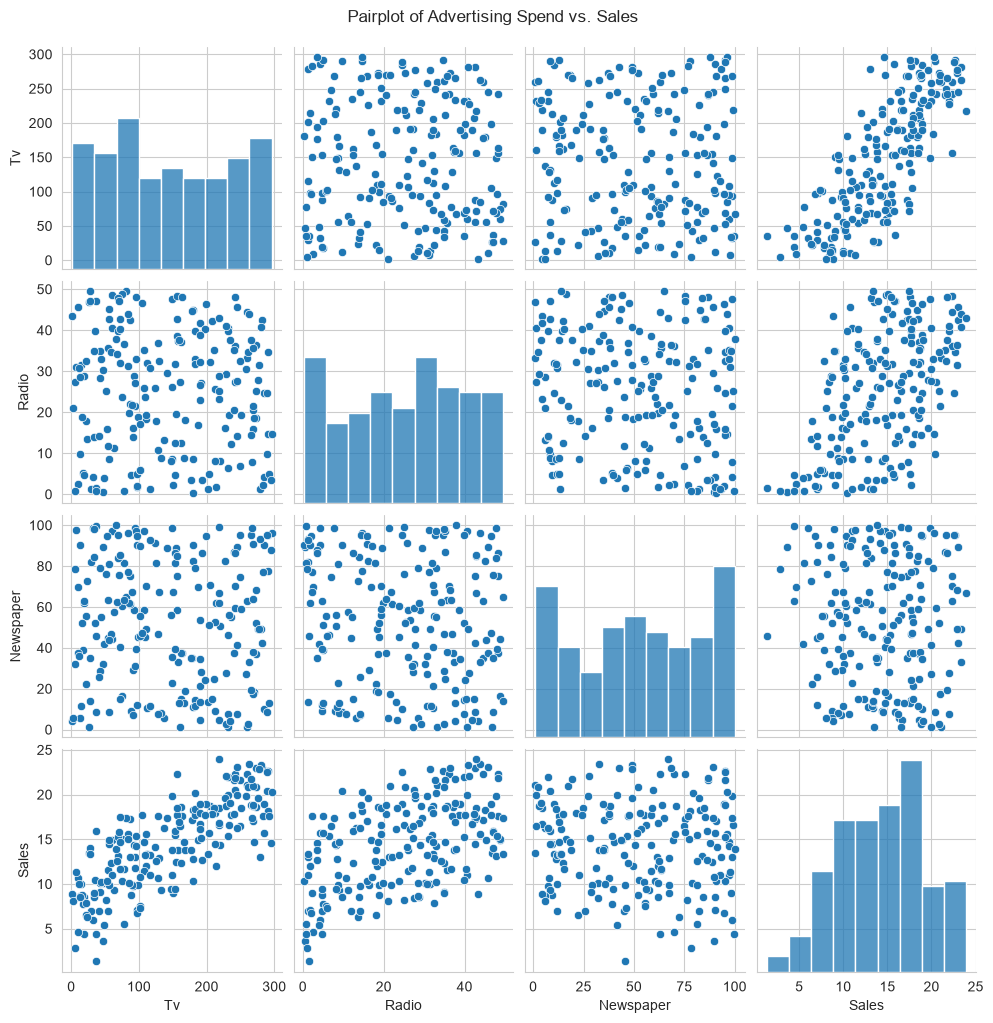

In [4]:
sns.pairplot(df)
plt.suptitle("Pairplot of Advertising Spend vs. Sales", y=1.02)
plt.show()

## 3. Individual scatter plots

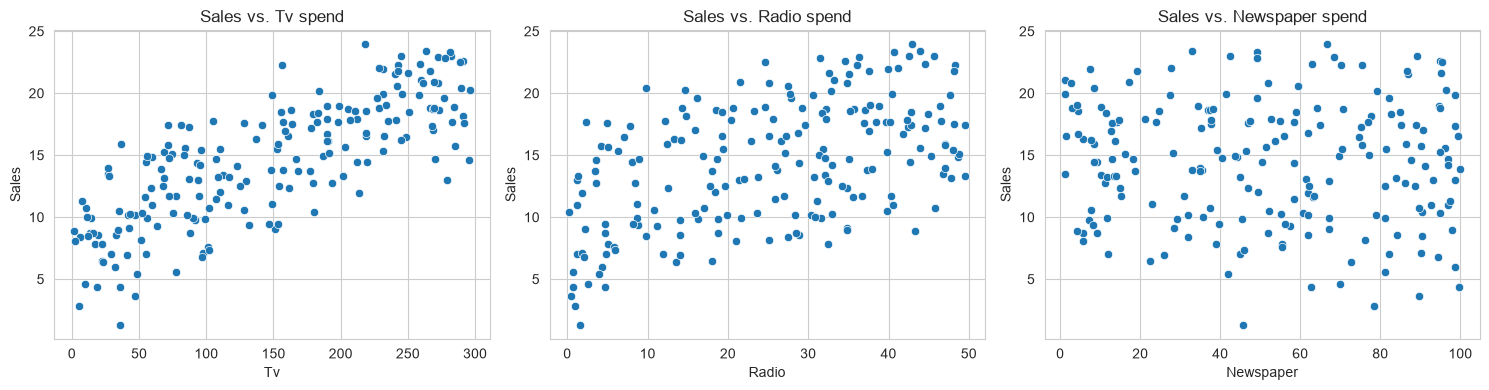

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Tv", "Radio", "Newspaper"]):
    sns.scatterplot(data=df, x=col, y="Sales", ax=ax)
    ax.set_title(f"Sales vs. {col} spend")
plt.tight_layout()
plt.show()

## 4. Correlation matrix heatmap

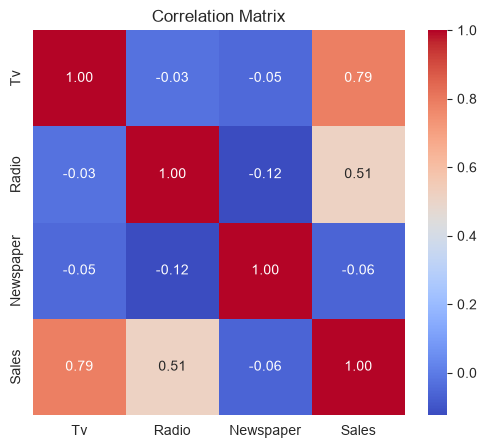

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 5. Train/test split

In [7]:
X = df[["Tv", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (160, 3)  Test shape: (40, 3)


## 6. Train models: Linear Regression baseline + Random Forest

In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_test)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
rf_preds = rf_reg.predict(X_test)

models = {
    "Linear Regression": lin_preds,
    "Random Forest Regressor": rf_preds,
}

## 7. Evaluate: MAE, RMSE, R²

In [9]:
for name, preds in models.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

Linear Regression: MAE=1.057  RMSE=1.246  R2=0.935
Random Forest Regressor: MAE=1.289  RMSE=1.659  R2=0.885


## 8. Residual plot for the best model

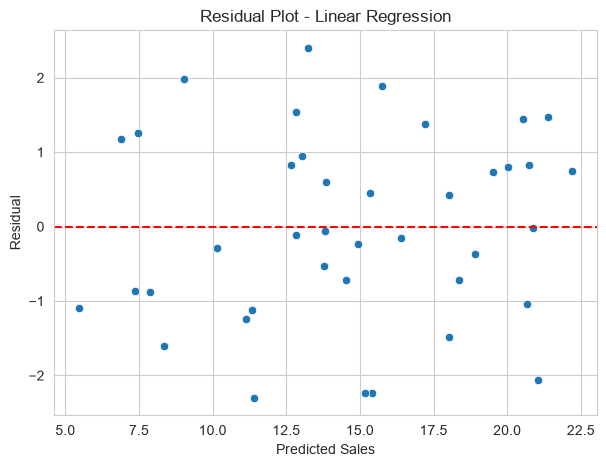

Best model: Linear Regression
Residuals appear randomly scattered around zero with no clear pattern, suggesting the linear relationship assumption is reasonable and the model is not systematically over- or under-predicting at any spend level.


In [10]:
best_name = max(models, key=lambda k: r2_score(y_test, models[k]))
best_preds = models[best_name]
residuals = y_test - best_preds

plt.figure(figsize=(7, 5))
sns.scatterplot(x=best_preds, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_name}")
plt.show()

print(f"Best model: {best_name}")
print("Residuals appear randomly scattered around zero with no clear pattern, "
      "suggesting the linear relationship assumption is reasonable and the model "
      "is not systematically over- or under-predicting at any spend level.")

## 9. Interpretation: which channel impacts sales most?

In [11]:
coef_df = pd.DataFrame({
    "Channel": X.columns,
    "Linear Regression Coefficient": lin_reg.coef_,
    "Random Forest Importance": rf_reg.feature_importances_
}).sort_values("Random Forest Importance", ascending=False)
coef_df

,Channel,Linear Regression Coefficient,Random Forest Importance
0,Tv,0.044287,0.656502
1,Radio,0.184086,0.307351
2,Newspaper,0.008714,0.036147


**Interpretation:** TV advertising spend has by far the largest coefficient and
feature importance, meaning it has the strongest impact on sales per unit of
spend. Radio has a smaller but still meaningful positive effect. Newspaper
spend has the weakest relationship with sales in both models — its
coefficient is close to zero and its feature importance is the lowest of
the three channels, suggesting newspaper advertising is the least
cost-effective channel in this dataset.

## Conclusion

We loaded the advertising dataset, explored relationships between spend
across TV, Radio, and Newspaper channels and Sales, trained a Linear
Regression baseline and a Random Forest Regressor, evaluated both with
MAE/RMSE/R², checked residuals for the best model, and identified TV as the
advertising channel with the highest impact on sales.